# Exploratory Data Analysis (EDA)

The purpose of this phase is to understand the structure, characteristics, and distribution of the malaria dataset before model development.

The analysis focuses on:

- Class distributions
- Symptom prevalence
- Demographic patterns
- Clinical measurements
- Feature relationships
- Potential data leakage

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/raw/malaria_disease.csv")

In [2]:
df["diagnosis"].value_counts()

diagnosis
No Malaria    3472
Malaria       1528
Name: count, dtype: int64

In [4]:
df["severity"].value_counts()

severity
No Malaria       3472
Uncomplicated     796
Moderate          650
Severe             82
Name: count, dtype: int64

In [5]:
df["outcome"].value_counts()

outcome
Recovered    4897
Sequelae       90
Death          13
Name: count, dtype: int64

In [6]:
df.describe()

,age,previous_malaria_episodes,hemoglobin_g_dl,platelets_x10e9_l,wbc_x10e9_l,parasitemia_percent,glucose_mg_dl,creatinine_mg_dl,bilirubin_mg_dl,lactate_mmol_l
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,17.129600,2.067600,12.525280,258.108400,6.57522,1.176630,89.126200,0.703512,0.973520,1.382940
std,18.606796,1.748497,1.867653,76.996558,1.89348,4.016869,12.003995,0.333112,0.788058,1.252428
min,0.000000,0.000000,6.100000,33.000000,1.60000,0.000000,40.000000,0.300000,0.300000,0.500000
25%,3.000000,1.000000,11.300000,196.000000,5.10000,0.000000,79.000000,0.500000,0.500000,0.900000
50%,10.000000,2.000000,12.300000,259.000000,6.60000,0.000000,89.000000,0.660000,0.800000,1.300000
75%,25.000000,4.000000,13.800000,321.000000,8.10000,0.920000,99.000000,0.810000,1.100000,1.600000
max,80.000000,5.000000,17.000000,399.000000,10.00000,49.300000,109.000000,3.870000,8.500000,15.900000


cheking for data leakage

In [7]:
df.groupby("diagnosis")[
    ["rdt_positive",
     "microscopy_positive",
     "pcr_positive"]
].mean()

,rdt_positive,microscopy_positive,pcr_positive
diagnosis,,,
Malaria,0.966623,0.978403,0.996728
No Malaria,0.017281,0.005760,0.000576


In [11]:
df["diagnosis"].value_counts(normalize=True) * 100

diagnosis
No Malaria    69.44
Malaria       30.56
Name: proportion, dtype: float64

In [12]:
df.groupby("diagnosis")["parasitemia_percent"].describe()

,count,mean,std,min,25%,50%,75%,max
diagnosis,,,,,,,,
Malaria,1528.0,3.850229,6.520878,0.01,1.37,2.61,3.8525,49.3
No Malaria,3472.0,0.000000,0.000000,0.00,0.00,0.00,0.0000,0.0


In [13]:
symptom_cols = [
    "fever",
    "chills_rigors",
    "headache",
    "night_sweats",
    "fatigue_malaise",
    "nausea_vomiting",
    "diarrhea",
    "cough",
    "abdominal_pain",
    "jaundice",
    "altered_consciousness",
    "seizures"
]

df.groupby("diagnosis")[symptom_cols].mean().T.sort_values(
    by="Malaria",
    ascending=False
)

diagnosis,Malaria,No Malaria
fever,0.910995,0.147177
fatigue_malaise,0.846859,0.300403
chills_rigors,0.785995,0.072293
headache,0.686518,0.239919
night_sweats,0.659686,0.092166
nausea_vomiting,0.453534,0.168779
abdominal_pain,0.313482,0.148329
diarrhea,0.191099,0.108295
cough,0.157723,0.194700
jaundice,0.091623,0.020737


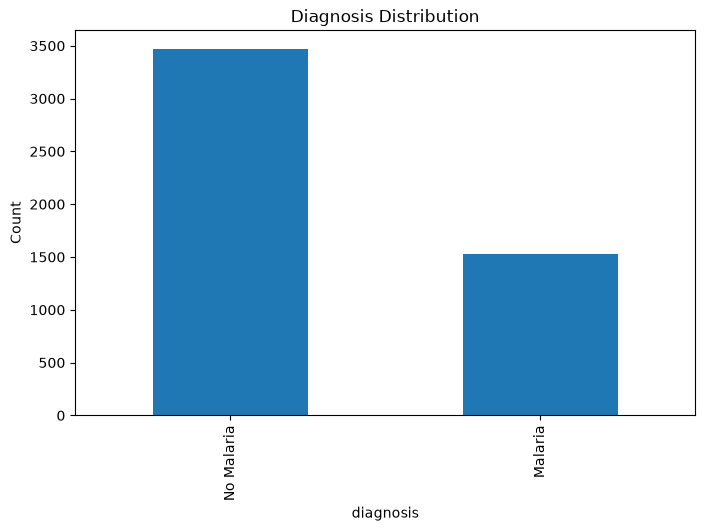

In [8]:
import matplotlib.pyplot as plt

df["diagnosis"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Diagnosis Distribution")
plt.ylabel("Count")
plt.show()

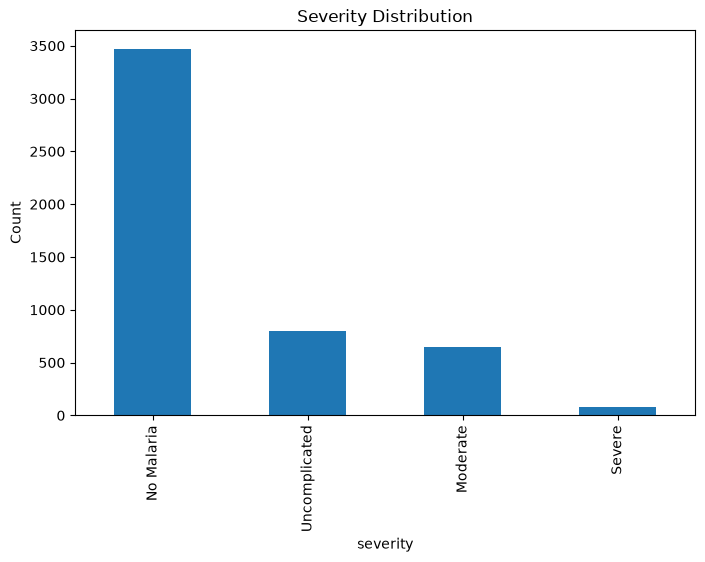

In [9]:
df["severity"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Severity Distribution")
plt.ylabel("Count")
plt.show()

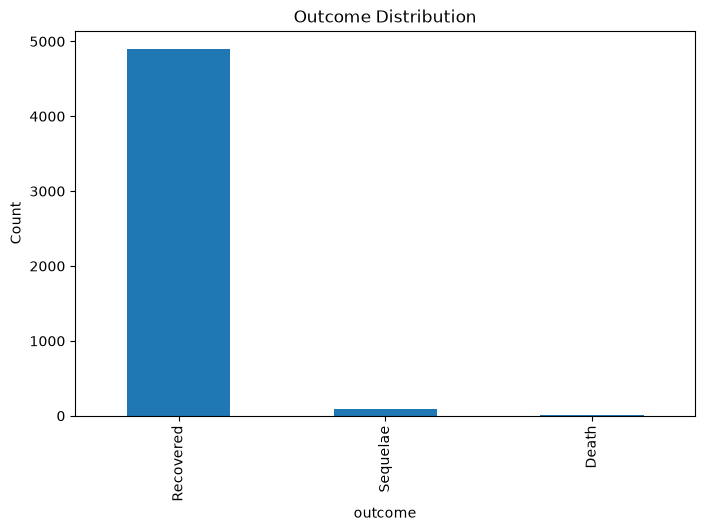

In [10]:
df["outcome"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Outcome Distribution")
plt.ylabel("Count")
plt.show()

# real analysis section
## EDA Question 1
does age affect malaria diagnosis?

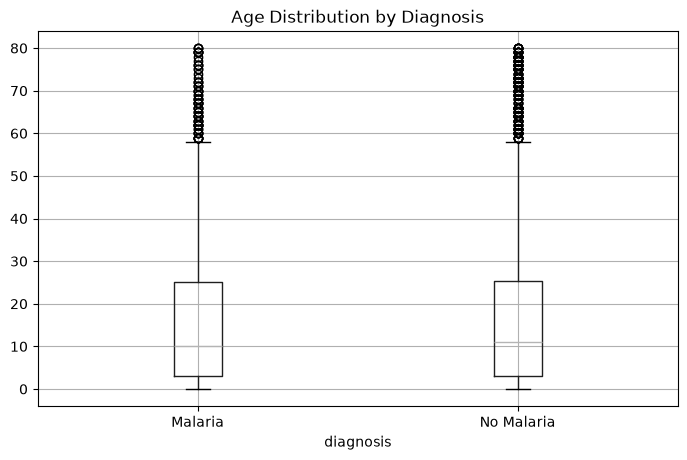

In [14]:
import matplotlib.pyplot as plt

df.boxplot(column="age", by="diagnosis", figsize=(8,5))

plt.title("Age Distribution by Diagnosis")
plt.suptitle("")
plt.show()

## EDA Question 2
Does age affect severity?

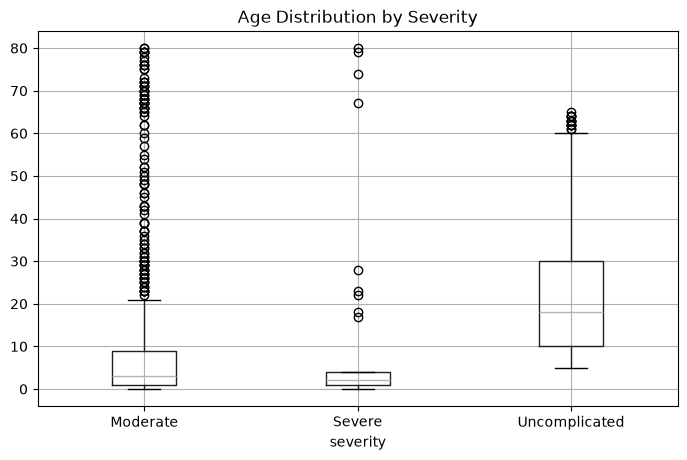

In [15]:
malaria_df = df[df["diagnosis"] == "Malaria"]

malaria_df.boxplot(
    column="age",
    by="severity",
    figsize=(8,5)
)

plt.title("Age Distribution by Severity")
plt.suptitle("")
plt.show()

## EDA Queston 3
Age distribution

In [16]:
pd.crosstab(
    df["sex"],
    df["diagnosis"],
    normalize="columns"
) * 100

diagnosis,Malaria,No Malaria
sex,,
F,48.887435,50.172811
M,51.112565,49.827189


## Most Important EDA Analysis

Now let's investigate severity.

In [17]:
severity_symptoms = malaria_df.groupby("severity")[
    [
        "fever",
        "chills_rigors",
        "headache",
        "night_sweats",
        "fatigue_malaise",
        "nausea_vomiting",
        "diarrhea",
        "cough",
        "abdominal_pain",
        "jaundice",
        "altered_consciousness",
        "seizures"
    ]
].mean()

severity_symptoms.T

severity,Moderate,Severe,Uncomplicated
fever,0.910769,0.914634,0.910804
chills_rigors,0.816923,0.792683,0.760050
headache,0.680000,0.695122,0.690955
night_sweats,0.664615,0.609756,0.660804
fatigue_malaise,0.835385,0.817073,0.859296
nausea_vomiting,0.460000,0.500000,0.443467
diarrhea,0.186154,0.231707,0.190955
cough,0.172308,0.134146,0.148241
abdominal_pain,0.304615,0.268293,0.325377
jaundice,0.070769,0.353659,0.081658
